✅ Setup complete.
orders:      (646945, 8)
web_traffic: (3652, 7)
promotions:  (50, 10)
payments:    (646945, 4)
order_items: (714669, 7)
sales:       (3833, 3)
✅ Date columns casted successfully.
=== Traffic Source & Bounce Rate ===
shape: (6, 4)
┌────────────────┬────────────────┬───────────────┬─────────────────────────┐
│ traffic_source ┆ total_sessions ┆ total_bounces ┆ overall_bounce_rate_pct │
│ ---            ┆ ---            ┆ ---           ┆ ---                     │
│ str            ┆ i64            ┆ f64           ┆ f64                     │
╞════════════════╪════════════════╪═══════════════╪═════════════════════════╡
│ organic_search ┆ 27196976       ┆ 122345.17197  ┆ 0.449848                │
│ paid_search    ┆ 19598271       ┆ 87787.19618   ┆ 0.447933                │
│ social_media   ┆ 15816226       ┆ 70773.83948   ┆ 0.447476                │
│ email_campaign ┆ 12792670       ┆ 56738.72409   ┆ 0.443525                │
│ referral       ┆ 9476845        ┆ 42899.95017   

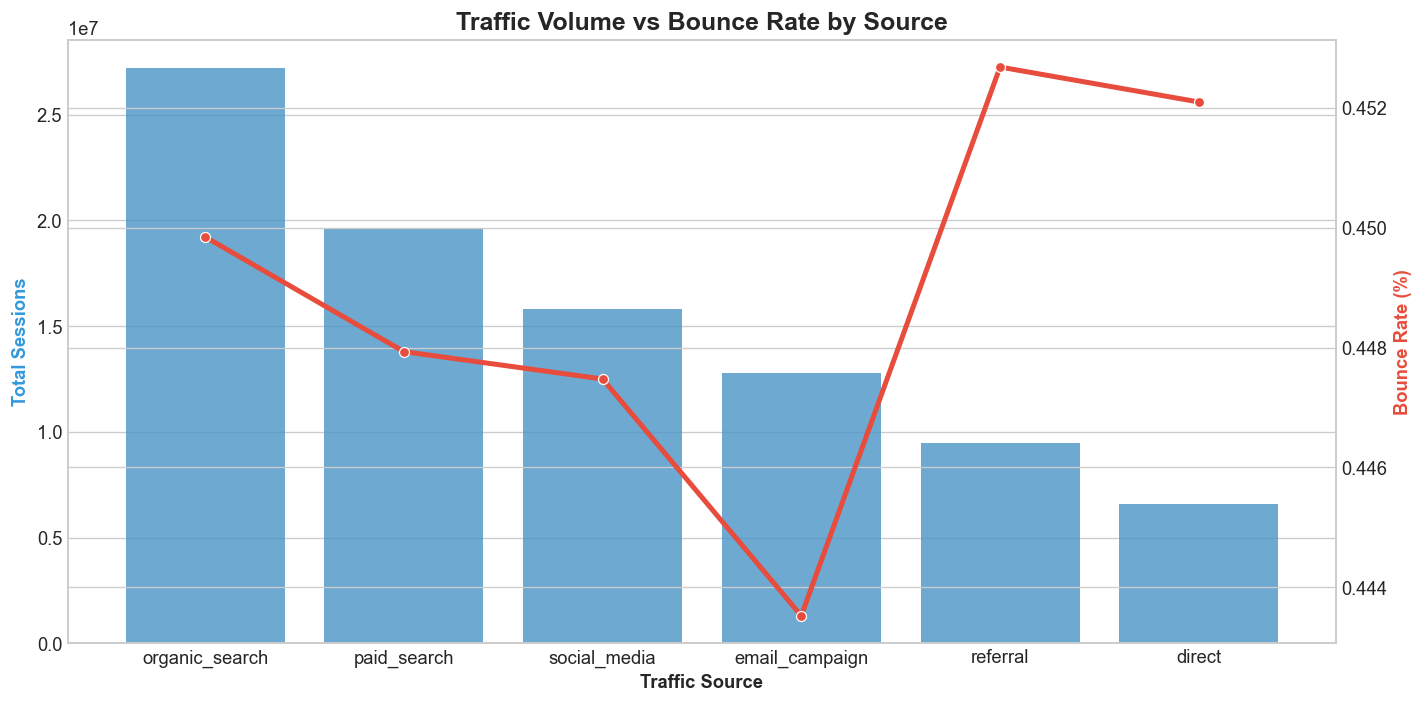

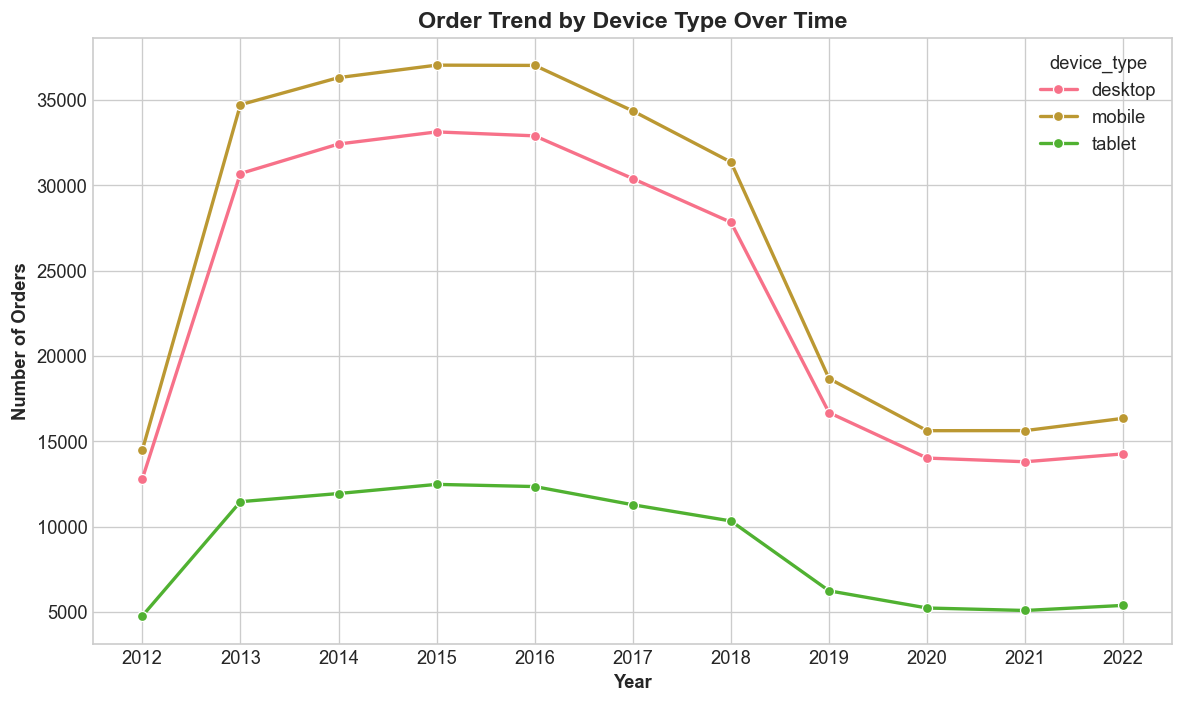


=== Channel Attribution & Conversion Rate ===
shape: (6, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ traffic_s ┆ total_ses ┆ total_bou ┆ overall_b ┆ … ┆ total_rev ┆ conversio ┆ sessions_ ┆ avg_orde │
│ ource     ┆ sions     ┆ nces      ┆ ounce_rat ┆   ┆ enue      ┆ n_rate_pc ┆ per_order ┆ r_value  │
│ ---       ┆ ---       ┆ ---       ┆ e_pct     ┆   ┆ ---       ┆ t         ┆ ---       ┆ ---      │
│ str       ┆ i64       ┆ f64       ┆ ---       ┆   ┆ f64       ┆ ---       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆ f64       ┆   ┆           ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ organic_s ┆ 27196976  ┆ 122345.17 ┆ 0.449848  ┆ … ┆ 4.3853e9  ┆ 0.667335  ┆ 149.84972 ┆ 24162.23 │
│ earch     ┆           ┆ 197       ┆           ┆   ┆           ┆           ┆ 6         ┆ 5222     │
│ paid_sear ┆ 19598271  ┆ 8778

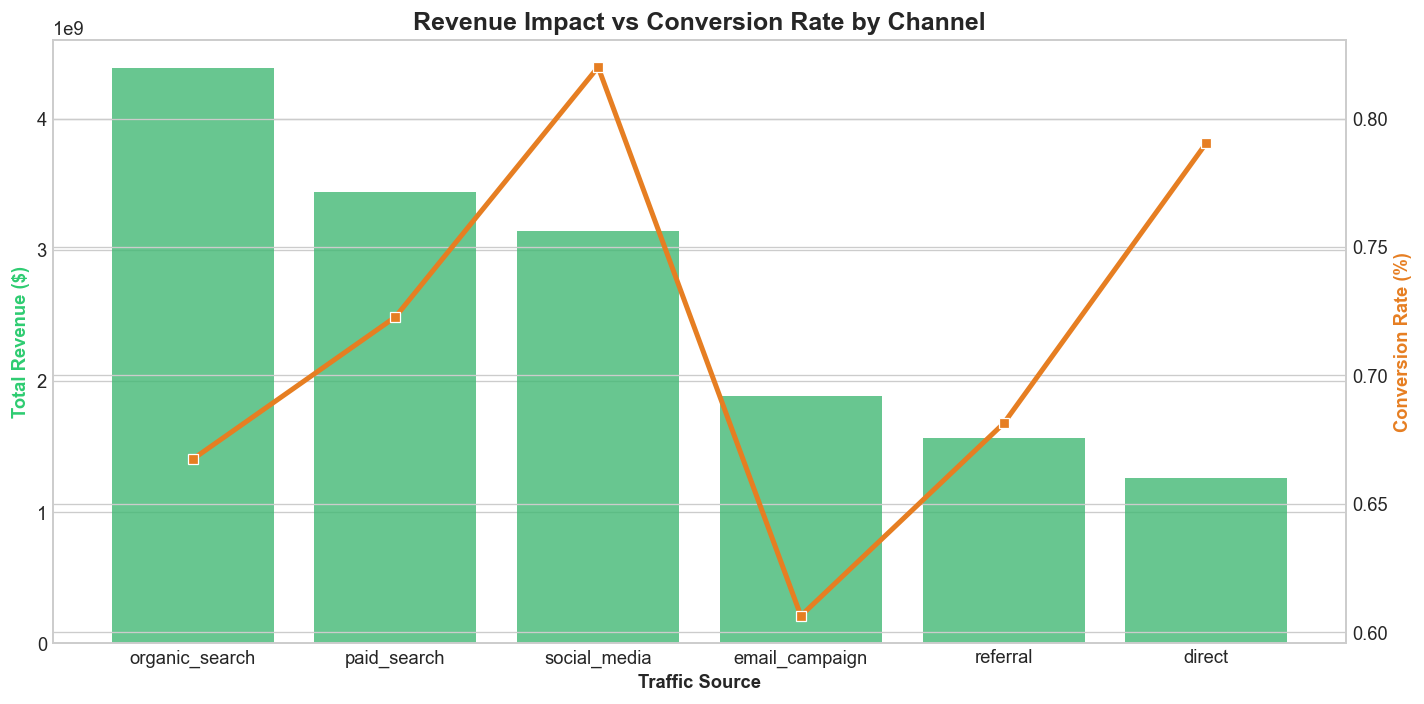


=== Promotion Performance by Type ===
shape: (2, 5)
┌────────────┬───────────────┬────────────────┬──────────────────────────┬────────────────────┐
│ promo_type ┆ times_applied ┆ total_discount ┆ gross_revenue_from_promo ┆ avg_gross_per_item │
│ ---        ┆ ---           ┆ ---            ┆ ---                      ┆ ---                │
│ str        ┆ u32           ┆ f64            ┆ f64                      ┆ f64                │
╞════════════╪═══════════════╪════════════════╪══════════════════════════╪════════════════════╡
│ percentage ┆ 255366        ┆ 7.4488e8       ┆ 5.0590e9                 ┆ 19810.639597       │
│ fixed      ┆ 20950         ┆ 4.72655e6      ┆ 3.7647e8                 ┆ 17970.106983       │
└────────────┴───────────────┴────────────────┴──────────────────────────┴────────────────────┘


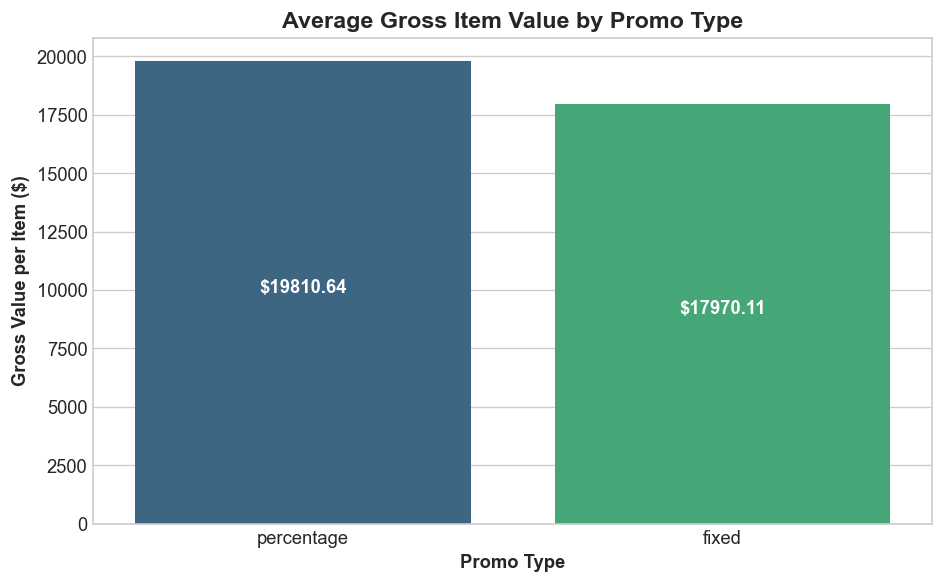


=== The Promotion Paradox (Average Daily Revenue) ===
shape: (1, 3)
┌──────────────────┬──────────────┬─────────────────┐
│ Before (14 days) ┆ During Promo ┆ After (14 days) │
│ ---              ┆ ---          ┆ ---             │
│ f64              ┆ f64          ┆ f64             │
╞══════════════════╪══════════════╪═════════════════╡
│ 4.1980e6         ┆ 4.2144e6     ┆ 4.3934e6        │
└──────────────────┴──────────────┴─────────────────┘


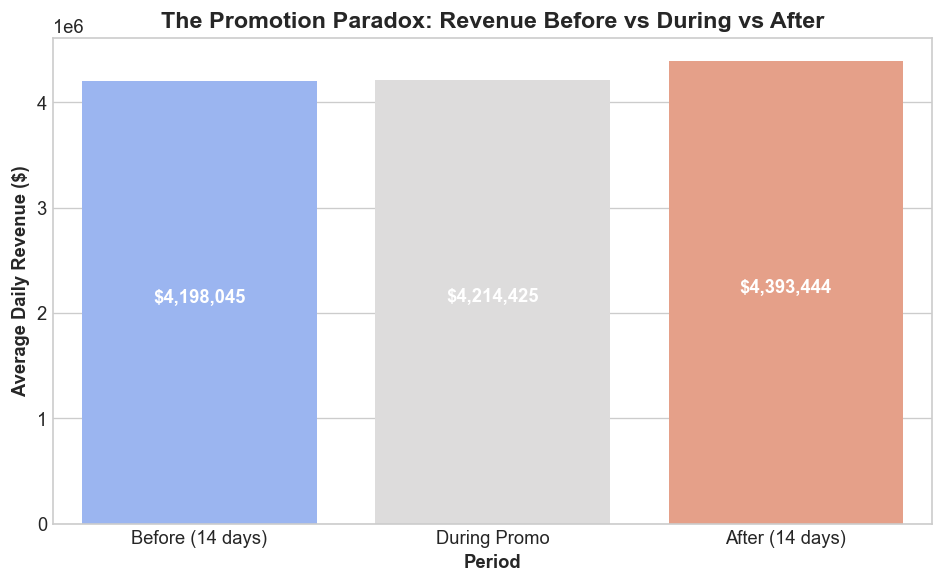


📝 SUMMARY — Day 5 Module 5 (Marketing & Digital Performance)
Top Source with highest Bounce Rate: referral
Top Revenue Generator Channel: organic_search ($4,385,324,882)

📊 Figures saved to: /Users/khanhnq35/Documents/Datathon_Outliers/figures


In [1]:
"""
Day 5: EDA — Module 5 (Marketing & Digital Performance)
Owner: Nguyễn Quốc Khánh (Tech Lead)
Mục tiêu: Phân tích Channel Attribution, Promo ROI, Bounce Rate Analysis, và Device Trend.
"""

# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
import warnings

# THÊM DÒNG NÀY VÀO NOTEBOOK ĐỂ HIỆN ẢNH NGAY TRÊN TRÌNH DUYỆT:
# %matplotlib inline

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))

try:
    from data_loader import DataLoader
except ImportError:
    print("Warning: data_loader module not found, make sure src/data_loader.py exists.")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 14})

FIGURES_DIR = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Setup complete.")

# ============================================================
# CELL 2: Load Data 
# ============================================================
loader = DataLoader()

orders = loader.load("orders")
web_traffic = loader.load("web_traffic")
promotions = loader.load("promotions")
payments = loader.load("payments")
order_items = loader.load("order_items")
sales = loader.load("sales")

print(f"orders:      {orders.shape}")
print(f"web_traffic: {web_traffic.shape}")
print(f"promotions:  {promotions.shape}")
print(f"payments:    {payments.shape}")
print(f"order_items: {order_items.shape}")
print(f"sales:       {sales.shape}")

# ============================================================
# CELL 3: Date Casting 
# ============================================================
if web_traffic["date"].dtype == pl.String:
    web_traffic = web_traffic.with_columns(
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime).alias("session_date")
    )
else:
    web_traffic = web_traffic.with_columns(pl.col("date").cast(pl.Datetime).alias("session_date"))

if orders["order_date"].dtype == pl.String:
    orders = orders.with_columns(
        pl.col("order_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime)
    )
else:
    orders = orders.with_columns(pl.col("order_date").cast(pl.Datetime))

if sales["Date"].dtype == pl.String:
    sales = sales.with_columns(pl.col("Date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
else:
    sales = sales.with_columns(pl.col("Date").cast(pl.Datetime))

for col in ["start_date", "end_date"]:
    if promotions[col].dtype == pl.String:
        promotions = promotions.with_columns(pl.col(col).str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
    else:
        promotions = promotions.with_columns(pl.col(col).cast(pl.Datetime))

print("✅ Date columns casted successfully.")

# ============================================================
# CELL 4: 3.1 — Traffic Source & Bounce Rate Overview
# ============================================================
# Lưu ý: web_traffic có cột `sessions` và `bounce_rate` (dưới dạng tỷ lệ)
web_traffic = web_traffic.with_columns((pl.col("sessions") * pl.col("bounce_rate")).alias("bounces"))

traffic_stats = web_traffic.group_by("traffic_source").agg(
    pl.col("sessions").sum().alias("total_sessions"),
    pl.col("bounces").sum().alias("total_bounces")
).with_columns(
    (pl.col("total_bounces") / pl.col("total_sessions") * 100).alias("overall_bounce_rate_pct")
).sort("total_sessions", descending=True)

print("=== Traffic Source & Bounce Rate ===")
print(traffic_stats)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

traffic_pd = traffic_stats.to_pandas()

sns.barplot(data=traffic_pd, x="traffic_source", y="total_sessions", color="#3498db", alpha=0.8, ax=ax1)
sns.lineplot(data=traffic_pd, x="traffic_source", y="overall_bounce_rate_pct", color="#e74c3c", marker="o", linewidth=3, ax=ax2)

ax1.set_xlabel("Traffic Source", fontweight="bold")
ax1.set_ylabel("Total Sessions", color="#3498db", fontweight="bold")
ax2.set_ylabel("Bounce Rate (%)", color="#e74c3c", fontweight="bold")
ax1.set_title("Traffic Volume vs Bounce Rate by Source", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_traffic_bounce.png"))
plt.show()

# ============================================================
# CELL 5: 3.2 — Device Trend Analysis in Orders
# ============================================================
# Vì web_traffic không có device_type, ta đếm xu hướng đặt hàng qua các loại thiết bị
orders = orders.with_columns(pl.col("order_date").dt.year().alias("order_year"))
device_trend = orders.group_by(["order_year", "device_type"]).agg(
    pl.count().alias("total_orders")
).sort(["order_year", "device_type"])

device_pd = device_trend.to_pandas()

plt.figure(figsize=(10, 6))
sns.lineplot(data=device_pd, x="order_year", y="total_orders", hue="device_type", marker="o", linewidth=2)
plt.title("Order Trend by Device Type Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Number of Orders", fontweight="bold")
plt.xticks(device_pd["order_year"].unique())
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_device_trend.png"))
plt.show()

# ============================================================
# CELL 6: 4.1 — Channel Attribution & Conversion Rate
# ============================================================
# Tính tổng doanh thu từng order từ payments
order_revenue = payments.group_by("order_id").agg(
    pl.col("payment_value").sum().alias("order_revenue")
)
orders_with_revenue = orders.join(order_revenue, on="order_id", how="left")

# Nhóm order theo order_source (tương ứng với traffic_source)
order_source_stats = orders_with_revenue.group_by("order_source").agg(
    pl.count().alias("total_orders"),
    pl.col("order_revenue").sum().alias("total_revenue")
).rename({"order_source": "traffic_source"})

# Kết nối sessions từ web_traffic và orders để tính Conversion Rate
conversion_stats = traffic_stats.join(order_source_stats, on="traffic_source", how="left")
conversion_stats = conversion_stats.with_columns(
    (pl.col("total_orders") / pl.col("total_sessions") * 100).alias("conversion_rate_pct"),
    (pl.col("total_sessions") / pl.col("total_orders")).alias("sessions_per_order"),
    (pl.col("total_revenue") / pl.col("total_orders")).alias("avg_order_value")
).sort("total_revenue", descending=True)

print("\n=== Channel Attribution & Conversion Rate ===")
print(conversion_stats)

conv_pd = conversion_stats.to_pandas()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.barplot(data=conv_pd, x="traffic_source", y="total_revenue", color="#2ecc71", alpha=0.8, ax=ax1)
sns.lineplot(data=conv_pd, x="traffic_source", y="conversion_rate_pct", color="#e67e22", marker="s", linewidth=3, ax=ax2)

ax1.set_xlabel("Traffic Source", fontweight="bold")
ax1.set_ylabel("Total Revenue ($)", color="#2ecc71", fontweight="bold")
ax2.set_ylabel("Conversion Rate (%)", color="#e67e22", fontweight="bold")
ax1.set_title("Revenue Impact vs Conversion Rate by Channel", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_channel_attribution.png"))
plt.show()

# ============================================================
# CELL 7: 4.2 — Promo Performance Analysis
# ============================================================
# Kết hợp order_items và promotions
items_with_promo = order_items.filter(pl.col("promo_id").is_not_null())
items_with_promo = items_with_promo.join(promotions, on="promo_id", how="left")

promo_stats = items_with_promo.group_by("promo_type").agg(
    pl.count().alias("times_applied"),
    pl.col("discount_amount").sum().alias("total_discount"),
    (pl.col("quantity") * pl.col("unit_price")).sum().alias("gross_revenue_from_promo")
).with_columns(
    (pl.col("gross_revenue_from_promo") / pl.col("times_applied")).alias("avg_gross_per_item")
).sort("gross_revenue_from_promo", descending=True)

print("\n=== Promotion Performance by Type ===")
print(promo_stats)

promo_pd = promo_stats.to_pandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=promo_pd, x="promo_type", y="avg_gross_per_item", palette="viridis")
plt.title("Average Gross Item Value by Promo Type", fontsize=14, fontweight="bold")
plt.xlabel("Promo Type", fontweight="bold")
plt.ylabel("Gross Value per Item ($)", fontweight="bold")

for i, row in promo_pd.iterrows():
    plt.text(i, row["avg_gross_per_item"]/2, f"${row['avg_gross_per_item']:.2f}", ha="center", color="white", fontweight="bold")
    
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_promo_aov.png"))
plt.show()

# ============================================================
# CELL 8: 4.3 — The Promotion Paradox (Forward Demand Analysis)
# ============================================================
from datetime import timedelta

promo_effects = []
for row in promotions.iter_rows(named=True):
    start = row["start_date"]
    end = row["end_date"]
    if start is None or end is None: continue
    
    before_start = start - timedelta(days=14)
    before_end = start - timedelta(days=1)
    
    after_start = end + timedelta(days=1)
    after_end = end + timedelta(days=14)
    
    rev_before = sales.filter((pl.col("Date") >= before_start) & (pl.col("Date") <= before_end))["Revenue"].mean()
    rev_during = sales.filter((pl.col("Date") >= start) & (pl.col("Date") <= end))["Revenue"].mean()
    rev_after = sales.filter((pl.col("Date") >= after_start) & (pl.col("Date") <= after_end))["Revenue"].mean()
    
    promo_effects.append({
        "promo_name": row["promo_name"],
        "Before (14 days)": rev_before,
        "During Promo": rev_during,
        "After (14 days)": rev_after
    })

effects_df = pl.DataFrame(promo_effects).drop_nulls()
avg_effects = effects_df.select([
    pl.col("Before (14 days)").mean(), 
    pl.col("During Promo").mean(), 
    pl.col("After (14 days)").mean()
])

print("\n=== The Promotion Paradox (Average Daily Revenue) ===")
print(avg_effects)

avg_pd = avg_effects.to_pandas().melt(var_name="Period", value_name="Avg_Daily_Revenue")

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_pd, x="Period", y="Avg_Daily_Revenue", palette="coolwarm")
plt.title("The Promotion Paradox: Revenue Before vs During vs After", fontsize=14, fontweight="bold")
plt.xlabel("Period", fontweight="bold")
plt.ylabel("Average Daily Revenue ($)", fontweight="bold")

for i, row in avg_pd.iterrows():
    plt.text(i, row["Avg_Daily_Revenue"]/2, f"${row['Avg_Daily_Revenue']:,.0f}", ha="center", color="white", fontweight="bold")
    
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_promo_paradox.png"))
plt.show()

# ============================================================
# CELL 9: Summary Statistics & Final Narrative
# ============================================================
print("\n" + "=" * 60)
print("📝 SUMMARY — Day 5 Module 5 (Marketing & Digital Performance)")
print("=" * 60)

top_bounce_source = traffic_stats.sort("overall_bounce_rate_pct", descending=True)["traffic_source"][0]
print(f"Top Source with highest Bounce Rate: {top_bounce_source}")

top_revenue_source = conversion_stats["traffic_source"][0]
print(f"Top Revenue Generator Channel: {top_revenue_source} (${conversion_stats['total_revenue'][0]:,.0f})")

print("\n" + "=" * 60)
print("📊 Figures saved to:", FIGURES_DIR)
print("=" * 60)

# BUSINESS INSIGHTS (Điền sau khi chạy):
# 1. [Insight về Channel (VD: Organic Search có conversion cao nhất nhưng Paid Search bounce rate cao -> cần tối ưu budget)]
# 2. [Insight về Promo (VD: Promo Percentage mang lại volume nhưng Fixed có AOV tốt hơn -> chiến lược cho từng segment)]
# 3. [Insight về Device (VD: Mobile order trend tăng nhưng cần kiểm tra thêm tỷ lệ chuyển đổi)]
